GTEx（Genotype-Tissue Expression，基因型-组织表达）数据库，研究从来自449名生前健康的人类捐献者的7000多份尸检样本，涵盖44个组织（42种不同的组织类型），包括31个实体器官组织、10个闹分区、全血、2个来自捐献者血液和皮肤的细胞系，作者利用这些样本研究基因表达在不同组织和个体中有何差异。

GTEx对几乎所有转录基因的基因表达模式进行了观察，从而能够确定基因组中影响基因表达的特定区域。

此外，合并GTEx与TCGA数据库数据能够有效解决TCGA数据库中正常组织样本量不足的缺陷，从而提高比较的准确性。

In [3]:
rm(list = ls())
options(stringsAsFactors = FALSE)
getwd()

[1] "/Users/luye/Library/Mobile Documents/com~apple~CloudDocs/Projects/Done/TCGA"

In [4]:
library(stringr)
library(dplyr)
library(ggplot2)
library(RColorBrewer)
library(data.table)
library(tibble)

## **Load GTEx data**

In [5]:
#表达矩阵
exp_gtex.tpm=fread("./GTEX/gtex_RSEM_gene_tpm.gz",header = T, sep = '\t',data.table = F)
rownames(exp_gtex.tpm)=exp_gtex.tpm[,1]
exp_gtex.tpm=exp_gtex.tpm[,-1]

In [6]:
head(exp_gtex.tpm)

,GTEX-S4Q7-0003-SM-3NM8M,GTEX-QV31-1626-SM-2S1QC,GTEX-13QIC-0011-R1a-SM-5O9CJ,GTEX-ZPCL-0126-SM-4WWC8,GTEX-S33H-1226-SM-4AD69,GTEX-X88G-0426-SM-47JZ5,GTEX-ZAKK-0326-SM-5EGHA,GTEX-1399S-1726-SM-5L3DI,GTEX-ZF29-0926-SM-4WKFZ,GTEX-13W3W-2626-SM-5SIA2,...,GTEX-1399R-0426-SM-5IJE3,GTEX-YFCO-1626-SM-4W1Z3,GTEX-OOBK-2626-SM-2HMKY,GTEX-OHPJ-0006-SM-3LK6G,GTEX-1117F-2826-SM-5GZXL,GTEX-11ZTS-3326-SM-5LU9Y,GTEX-VJYA-0726-SM-4KL1T,GTEX-ZA64-2126-SM-5Q5A8,GTEX-Q2AG-2826-SM-2HMJQ,GTEX-XV7Q-0426-SM-4BRVN
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000242268.2,-3.4580,-9.9658,-9.9658,-9.9658,-2.7274,-3.4580,-3.4580,-2.5479,-2.8262,-9.9658,...,-1.5105,-9.9658,-2.5479,-9.9658,-3.6259,1.5165,-9.9658,-2.3884,0.0440,-3.3076
ENSG00000259041.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
ENSG00000270112.3,-3.6259,-2.1779,-1.8314,-9.9658,-9.9658,-3.1714,-1.2481,-6.5064,-9.9658,-0.5332,...,-3.3076,-1.9942,-9.9658,-9.9658,-9.9658,-2.9324,-9.9658,-9.9658,2.5852,-3.0469
ENSG00000167578.16,4.5988,4.6294,6.4989,5.5358,3.7269,5.5696,3.0181,5.8726,4.6201,3.4583,...,2.9356,5.0041,5.7181,5.1811,4.9402,6.0809,4.7410,5.3212,5.8110,5.9132
ENSG00000278814.1,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,...,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658
ENSG00000078237.5,2.2633,1.9931,1.1577,1.9377,-0.9132,0.9419,0.7748,2.3479,0.4125,1.1577,...,-0.8599,2.2990,2.3592,0.9419,1.6830,1.9749,2.4465,1.4228,0.7748,2.8055


In [7]:
#样本信息
data_cl=fread("./GTEX/GTEX_phenotype.gz",header = T, sep = '\t',data.table = F)
data_cl=data_cl[,c(1,3)]
names(data_cl)=c('Barcode','Tissue')
#data_cl=data_cl[data_cl$Tissue == 'Prostate',] #筛选出Prostate的数据

In [9]:
table(data_cl$Tissue)


 <not provided>  Adipose Tissue   Adrenal Gland         Bladder           Blood 
              5             621             161              13             595 
   Blood Vessel     Bone Marrow           Brain          Breast    Cervix Uteri 
            753             102            1426             221              11 
          Colon       Esophagus  Fallopian Tube           Heart          Kidney 
            384             805               7             493              38 
          Liver            Lung          Muscle           Nerve           Ovary 
            141             381             478             335             112 
       Pancreas       Pituitary        Prostate  Salivary Gland            Skin 
            203             126             122              71             977 
Small Intestine          Spleen         Stomach          Testis         Thyroid 
            106             121             209             208             366 
         Uterus          Va

In [10]:
#注释信息
annotat=fread("./GTEX/gencode.v23.annotation.gene.probemap",header = T, sep = '\t',data.table = F)
annotat=annotat[,c(1,2)]
rownames(annotat)=annotat[,1] #这里没有选择删去id这一列

In [11]:
head(annotat)

,id,gene
,<chr>,<chr>
ENSG00000223972.5,ENSG00000223972.5,DDX11L1
ENSG00000227232.5,ENSG00000227232.5,WASH7P
ENSG00000278267.1,ENSG00000278267.1,MIR6859-1
ENSG00000243485.3,ENSG00000243485.3,RP11-34P13.3
ENSG00000274890.1,ENSG00000274890.1,MIR1302-2
ENSG00000237613.2,ENSG00000237613.2,FAM138A


## **Data preparation**

In [12]:
#筛选
exp_gtex.tpm=exp_gtex.tpm[,colnames(exp_gtex.tpm) %in% data_cl$Barcode]
#还原为TPM
exp_gtex.tpm=2^exp_gtex.tpm-0.001

In [13]:
dim(exp_gtex.tpm)

[1] 60498  7862

In [14]:
#基因注释
exp_gtex.tpm=as.matrix(exp_gtex.tpm)
t_index=intersect(rownames(exp_gtex.tpm),rownames(annotat)) #行名取交集，t_index中是能够进行注释的probe_id
exp_gtex.tpm=exp_gtex.tpm[t_index,]
annotat=annotat[t_index,]
rownames(exp_gtex.tpm)=annotat$gene

In [15]:
#去除重复基因名
t_index1=order(rowMeans(exp_gtex.tpm),decreasing = T)
t_data_order=exp_gtex.tpm[t_index1,]
keep=!duplicated(rownames(t_data_order))#对于有重复的基因，保留第一次出现的那个，即行平均值大的那个
exp_gtex.tpm=t_data_order[keep,]#得到最后处理之后的表达谱矩阵

In [16]:
dim(exp_gtex.tpm)

[1] 58581  7862

In [ ]:
head(exp_gtex.tpm)

In [17]:
#读出
write.csv(exp_gtex.tpm, file = "exp_gtex.tpm.csv", quote = FALSE) 

In [20]:
data_cl <- data_cl[data_cl$Barcode %in% colnames(exp_gtex.tpm),]

In [21]:
dim(data_cl)

[1] 7862    2

In [ ]:
#读出
write.csv(data_cl, file = "tissue_gtex.csv", quote = FALSE) 

## **注释来自 TCGA 和 GTEx 的样本**

In [4]:
#################======= step1: clean GTEx pheno data   =======#################
gtex <- read.table("./Data/samplepair.txt", header=T, sep='\t')
head(gtex)

,TCGA,Detail,Tumor,Normal,GTEx,Num
,<chr>,<chr>,<int>,<int>,<chr>,<int>
1,ACC,adrenocortical cancer,77,0,Adrenal Gland,128
2,BLCA,bladder urothelial carcinoma,404,19,Bladder,9
3,BRCA,breast invasive carcinoma,1085,112,Breast,179
4,CESC,cervical & endocervical cancer,306,3,Cervix Uteri,10
5,CHOL,cholangiocarcinoma,36,9,-,0
6,COAD,colon adenocarcinoma,275,41,Colon,308


In [5]:
tcga_ref <- gtex[,1:2]

In [6]:
gtex$type <- paste0(gtex$TCGA, "_normal_GTEx")
gtex$sample_type <- "normal"
gtex <- gtex[,c("TCGA", "GTEx", "type", "sample_type")]
names(gtex)[1:2] <- c("tissue", "X_primary_site")
head(gtex)

,tissue,X_primary_site,type,sample_type
,<chr>,<chr>,<chr>,<chr>
1,ACC,Adrenal Gland,ACC_normal_GTEx,normal
2,BLCA,Bladder,BLCA_normal_GTEx,normal
3,BRCA,Breast,BRCA_normal_GTEx,normal
4,CESC,Cervix Uteri,CESC_normal_GTEx,normal
5,CHOL,-,CHOL_normal_GTEx,normal
6,COAD,Colon,COAD_normal_GTEx,normal


In [7]:
gp <- read.delim(file="./Data/GTEX_phenotype.gz", header=T, as.is = T)
gtex2tcga <- merge(gtex, gp, by="X_primary_site")
gtex_data <- gtex2tcga[,c(5,2:4)]
names(gtex_data)[1] <- "sample"
head(gtex_data)

,sample,tissue,type,sample_type
,<chr>,<chr>,<chr>,<chr>
1,GTEX-QMRM-0126-SM-4R1K9,ACC,ACC_normal_GTEx,normal
2,GTEX-S32W-0126-SM-4AD61,ACC,ACC_normal_GTEx,normal
3,GTEX-ZUA1-1926-SM-5E45E,ACC,ACC_normal_GTEx,normal
4,GTEX-ZY6K-0126-SM-5SIAM,ACC,ACC_normal_GTEx,normal
5,GTEX-ZYWO-0126-SM-5GZWQ,ACC,ACC_normal_GTEx,normal
6,GTEX-XQ3S-1726-SM-4BOOD,ACC,ACC_normal_GTEx,normal


In [8]:
write.table(gtex_data, "./Data/GTEx_pheno.txt", row.names=F, quote=F, sep='\t')

In [10]:
#################======= step2: clean a TCGA pheno data   =======#################
tcga <- read.delim(file="./Data/TCGA_phenotype_denseDataOnlyDownload.tsv.gz", header=T, as.is = T)
tcga <- merge(tcga_ref, tcga, by.y="X_primary_disease", by.x="Detail", all.y = T)
tcga <- tcga[tcga$sample_type %in% c("Primary Tumor", "Solid Tissue Normal"),]
head(tcga)

,Detail,TCGA,sample,sample_type_id,sample_type
,<chr>,<chr>,<chr>,<int>,<chr>
201,adrenocortical cancer,ACC,TCGA-OR-A5LE-01,1,Primary Tumor
202,adrenocortical cancer,ACC,TCGA-OR-A5L2-01,1,Primary Tumor
203,adrenocortical cancer,ACC,TCGA-OR-A5L5-01,1,Primary Tumor
204,adrenocortical cancer,ACC,TCGA-OR-A5LL-01,1,Primary Tumor
205,adrenocortical cancer,ACC,TCGA-OR-A5LF-01,1,Primary Tumor
206,adrenocortical cancer,ACC,TCGA-OR-A5LC-01,1,Primary Tumor


In [11]:
tcga$type <- ifelse(tcga$sample_type == 'Solid Tissue Normal',
                    paste(tcga$TCGA, "normal_TCGA", sep="_"), paste(tcga$TCGA, "tumor_TCGA", sep="_"))
tcga$sample_type <- ifelse(tcga$sample_type == 'Solid Tissue Normal', "normal", "tumor")
tcga <- tcga[, c(3,2,6,5)]
names(tcga)[2] <- "tissue"
head(tcga)

,sample,tissue,type,sample_type
,<chr>,<chr>,<chr>,<chr>
201,TCGA-OR-A5LE-01,ACC,ACC_tumor_TCGA,tumor
202,TCGA-OR-A5L2-01,ACC,ACC_tumor_TCGA,tumor
203,TCGA-OR-A5L5-01,ACC,ACC_tumor_TCGA,tumor
204,TCGA-OR-A5LL-01,ACC,ACC_tumor_TCGA,tumor
205,TCGA-OR-A5LF-01,ACC,ACC_tumor_TCGA,tumor
206,TCGA-OR-A5LC-01,ACC,ACC_tumor_TCGA,tumor


In [12]:
write.table(tcga, "./Data/tcga_pheno.txt", row.names = F, quote=F, sep='\t')

In [14]:
#################======= step3: remove samples without tpm data =======############
gtex_exp <-  fread("./Data/gtex_RSEM_gene_tpm.gz", data.table = F)
gtexS <- gtex_data[gtex_data$sample %in% colnames(gtex_exp)[-1], ]
head(gtexS)
dim(gtexS)

,sample,tissue,type,sample_type
,<chr>,<chr>,<chr>,<chr>
1,GTEX-QMRM-0126-SM-4R1K9,ACC,ACC_normal_GTEx,normal
2,GTEX-S32W-0126-SM-4AD61,ACC,ACC_normal_GTEx,normal
5,GTEX-ZYWO-0126-SM-5GZWQ,ACC,ACC_normal_GTEx,normal
6,GTEX-XQ3S-1726-SM-4BOOD,ACC,ACC_normal_GTEx,normal
7,GTEX-ZF2S-0126-SM-4WKFO,ACC,ACC_normal_GTEx,normal
8,GTEX-XV7Q-0226-SM-4BRVL,ACC,ACC_normal_GTEx,normal


[1] 7568    4

In [15]:
tcga_exp <- fread("./Data/tcga_RSEM_gene_tpm.gz", data.table = F)
tcgaS <- tcga[tcga$sample %in% colnames(tcga_exp)[-1], ]
tcga_gtex <- rbind(tcgaS, gtexS)
head(tcga_gtex)
dim(tcga_gtex)

,sample,tissue,type,sample_type
,<chr>,<chr>,<chr>,<chr>
201,TCGA-OR-A5LE-01,ACC,ACC_tumor_TCGA,tumor
203,TCGA-OR-A5L5-01,ACC,ACC_tumor_TCGA,tumor
204,TCGA-OR-A5LL-01,ACC,ACC_tumor_TCGA,tumor
206,TCGA-OR-A5LC-01,ACC,ACC_tumor_TCGA,tumor
207,TCGA-OR-A5JF-01,ACC,ACC_tumor_TCGA,tumor
208,TCGA-OR-A5K0-01,ACC,ACC_tumor_TCGA,tumor


[1] 17480     4

In [16]:
write.table(tcga_gtex, "./Data/tcga_gtex_sample.txt", row.names = F, quote=F, sep='\t')

## **提取感兴趣的基因**

In [18]:
rm(list = ls())
options(stringsAsFactors = FALSE)

In [19]:
target <- "ICAM1"

In [20]:
idmap <- read.delim("./Data/gencode.v23.annotation.gene.probemap", as.is = T)
tcga_exp <- fread("./Data/tcga_RSEM_gene_tpm.gz", data.table = F)
gtex_exp <- fread("./Data/gtex_RSEM_gene_tpm.gz", data.table = F)
tcga_gtex <- read.table("./Data/tcga_gtex_sample.txt", sep='\t', header = T)

In [21]:
id <- idmap$id[which(idmap$gene == target)]
id

[1] "ENSG00000090339.8"

In [22]:
tcga_data <- t(tcga_exp[tcga_exp$sample==id, colnames(tcga_exp) %in% c("sample", tcga_gtex$sample)])
tcga_data <- data.frame(tcga_data[-1,])
tcga_data <- rownames_to_column(tcga_data, "sample")
names(tcga_data)[2] <- "tpm"
head(tcga_data)

,sample,tpm
,<chr>,<chr>
1,TCGA-19-1787-01,3.6635
2,TCGA-S9-A7J2-01,1.7954
3,TCGA-G3-A3CH-11,2.5585
4,TCGA-EK-A2RE-01,4.1939
5,TCGA-44-6778-01,7.1192
6,TCGA-F4-6854-01,4.5268


In [23]:
gtex_data <- t(gtex_exp[gtex_exp$sample==id, colnames(gtex_exp)%in%c("sample", tcga_gtex$sample)])
gtex_data <- data.frame(gtex_data[-1,])
gtex_data <- rownames_to_column(gtex_data, "sample")
names(gtex_data)[2] <- "tpm"
head(gtex_data)

,sample,tpm
,<chr>,<chr>
1,GTEX-S4Q7-0003-SM-3NM8M,5.8123
2,GTEX-13QIC-0011-R1a-SM-5O9CJ,0.9642
3,GTEX-ZPCL-0126-SM-4WWC8,4.1962
4,GTEX-S33H-1226-SM-4AD69,1.5514
5,GTEX-1399S-1726-SM-5L3DI,7.2428
6,GTEX-ZF29-0926-SM-4WKFZ,1.7316


In [24]:
tmp  <- rbind(tcga_data, gtex_data)
exp <- merge(tmp, tcga_gtex, by = "sample", all.x = T)
exp <- exp[, c("tissue", "sample_type", "tpm")]
exp <- arrange(exp, tissue)
head(exp)

,tissue,sample_type,tpm
,<chr>,<chr>,<chr>
1,ACC,normal,3.8441
2,ACC,normal,2.7679
3,ACC,normal,2.3366
4,ACC,normal,3.4384
5,ACC,normal,2.9655
6,ACC,normal,2.7594


In [25]:
write.table(exp, "./Data/Merge ICAM1 expression.txt", row.names = F, quote=F, sep='\t')

## **可视化基因表达**

In [26]:
rm(list = ls())
options(stringsAsFactors = FALSE) 

In [28]:
library(ggplot2)
library(ggpubr)
library(RColorBrewer)

In [29]:
exp <- read.table("./Data/Merge ICAM1 expression.txt", header=T, sep='\t')
ylabname <- paste("ICAM1", "expression")
colnames(exp) <- c("Tissue", "Group", "Gene")
head(exp)

,Tissue,Group,Gene
,<chr>,<chr>,<dbl>
1,ACC,normal,3.8441
2,ACC,normal,2.7679
3,ACC,normal,2.3366
4,ACC,normal,3.4384
5,ACC,normal,2.9655
6,ACC,normal,2.7594


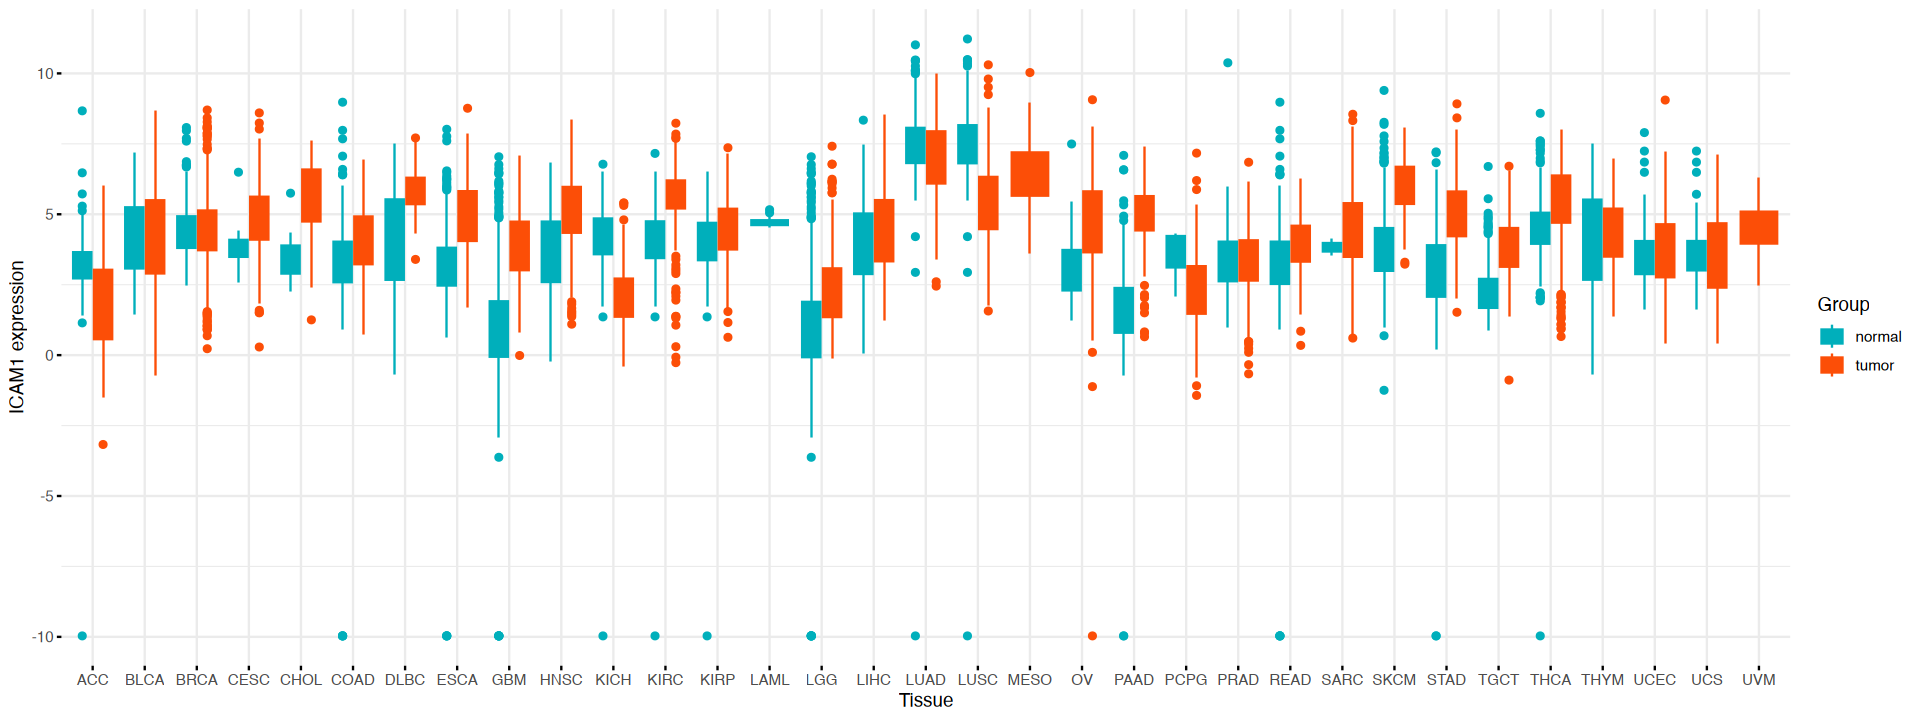

In [32]:
options(repr.plot.width=16, repr.plot.height=6)
p1 <- ggboxplot(exp, x = "Tissue", y = "Gene", fill = 'Group',
                ylab = ylabname,
                color = "Group", 
                palette = c("#00AFBB",  "#FC4E07"),
                ggtheme = theme_minimal())
p1

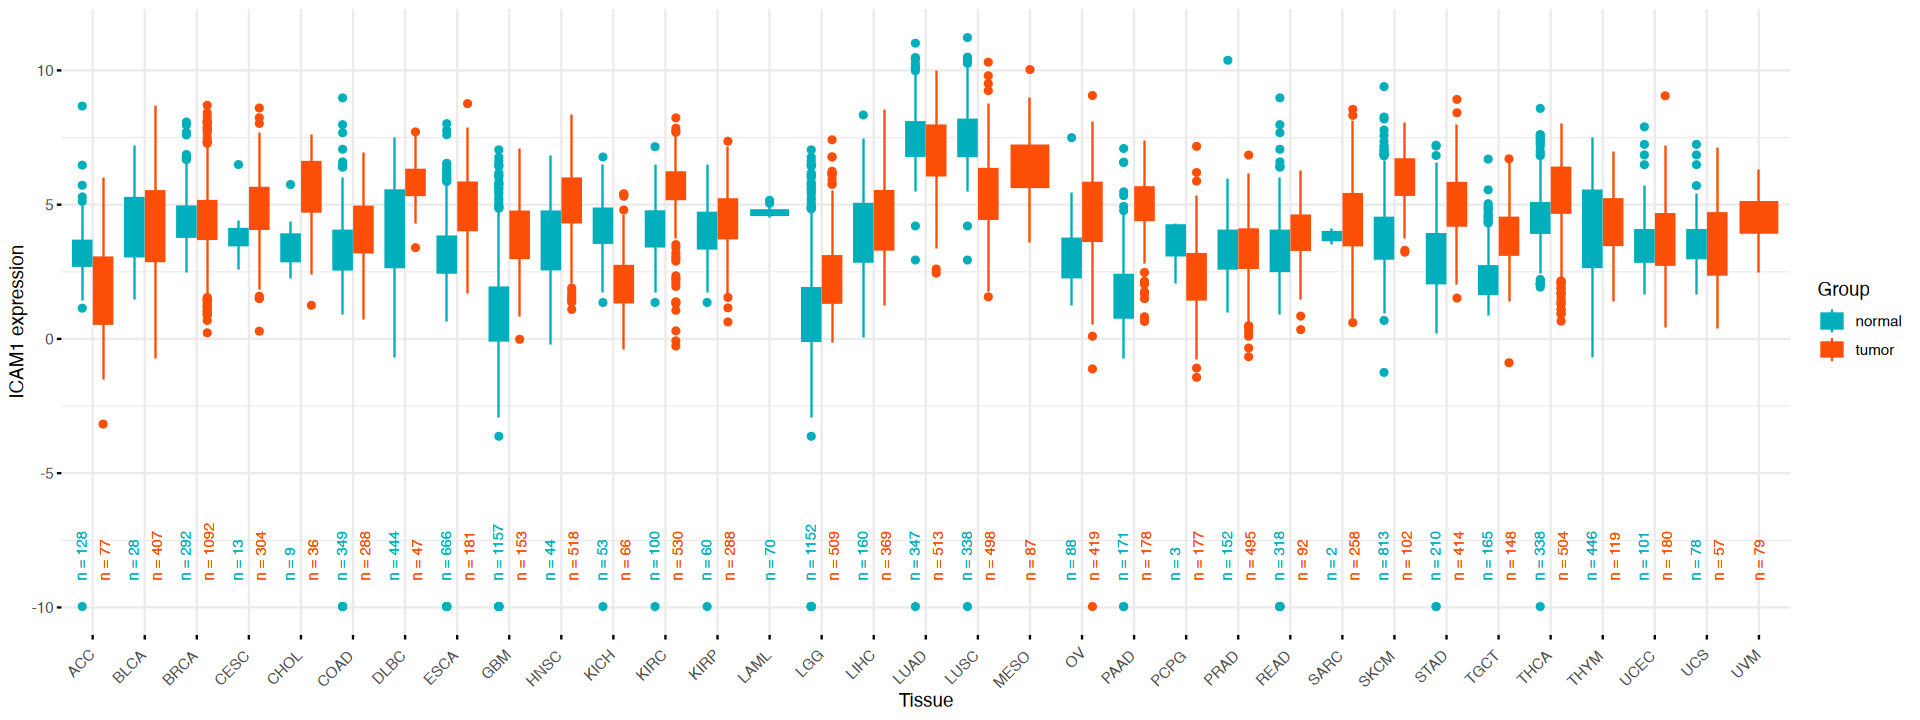

In [34]:
##计算每种肿瘤正常和肿瘤组织的样本量
count_N <- exp %>% group_by(Tissue, Group) %>% tally
count_N$n <- paste("n =", count_N$n)
##添加N = 到图中
p1 + geom_text(data=count_N, aes(label=n, y=-9,color=Group), position=position_dodge2(0.9),size = 3,angle=90, hjust = 0)+
  theme(axis.text.x = element_text(angle = 45,hjust = 1.2))

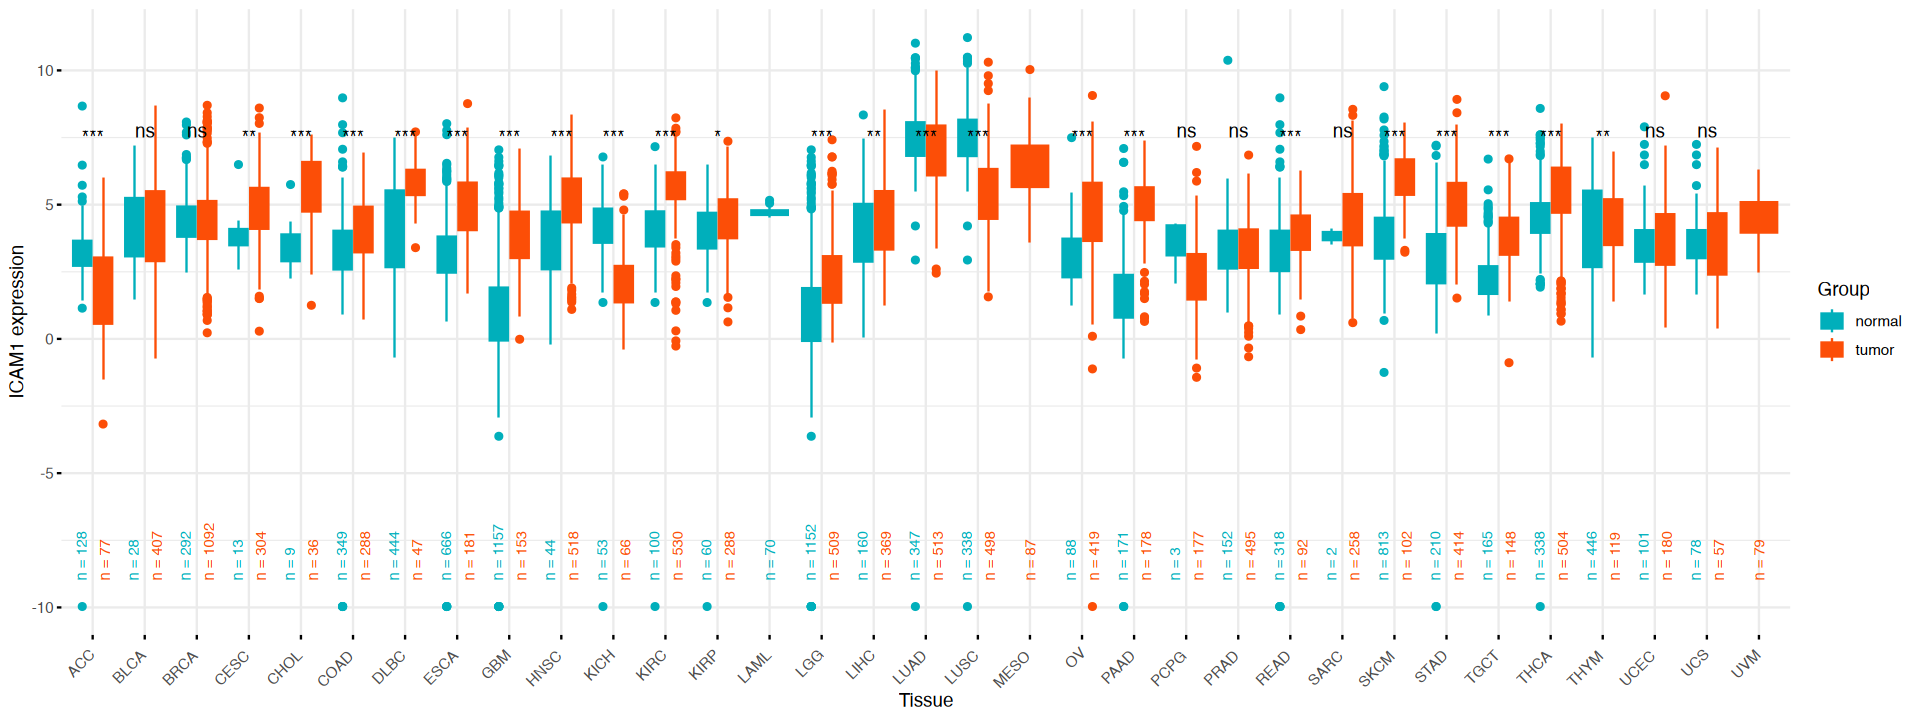

In [35]:
#计算t检验显著性
comp <- compare_means(Gene ~ Group, group.by = "Tissue", data = exp,
                         method = "t.test", symnum.args = list(cutpoints = c(0,0.001, 0.01, 0.05, 1), symbols = c( "***", "**", "*", "ns")),
                         p.adjust.method = "holm")
#添加显著性标记
p2 <- p1 + stat_pvalue_manual(comp, x = "Tissue", y.position = 7.5,
                     label = "p.signif", position = position_dodge(0.8))
p2
#dev.off()

In [ ]:
##保存图片
### pdf version
ggsave("figure/pancancer_Plot.pdf", width = 14, height = 5)

### png version
#png("figure/pancancer_Plot.png", width = 465, height = 225, units='mm', res = 300)

In [36]:
SKCM <- exp %>% filter(Tissue == "SKCM")

In [37]:
head(SKCM)

,Tissue,Group,Gene
,<chr>,<chr>,<dbl>
1,SKCM,normal,3.2617
2,SKCM,normal,3.6018
3,SKCM,normal,1.3623
4,SKCM,normal,2.3816
5,SKCM,normal,3.6680
6,SKCM,normal,1.4911


In [38]:
table(SKCM$Group)


normal  tumor 
   813    102 